# 二手房数据预测分析

## 1.图表工具模块

### 1.1 绘制饼图 

In [1]:
import matplotlib # 导入图表模块
import matplotlib.pyplot as plt # 导入绘图模块
# 避免中文乱码
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
#显示饼图
def pie_chart(size, label, title):
    plt.figure()
    plt.pie(size,labels=label,labeldistance=1.05,
           autopct="%1.1f%%",shadow=False,startangle=0,pctdistance=0.6)
    plt.axis("equal")   #设置横轴纵轴大小相等
    plt.title(title,fontsize=12)
    plt.legend(bbox_to_anchor=(0.03,1))   #让图例生效 并设置图例位置
    plt.show()

- 绘制饼图 size:各部分大小      labels：设置各部分标签       label distance：设置标签文本距离圆心位置，1.1表示1.1倍半径     autopct： 设置圆里的文本    shadow：设置是否阴影  startangle：起始角度 默认从0开始逆时针转  pctdistance：设置园内文本距离圆心距

### 1.2绘制折线图 

In [3]:
#显示预测房价折线图
def broken_line(y, y_pred, title):
    plt.figure()
    plt.plot(y,color='r',marker='o',label='真实房价')
    #绘制折线 并在折点添加蓝色圆点
    plt.plot(y_pred,color='b',marker='*',label='预测房价')
    plt.xlabel('房子数量')
    plt.ylabel('房子总价')
    plt.title(title)
    plt.legend()
    plt.grid()#显示网格
    plt.show()#显示图表

- y:轴折现点，也就是房子总价  y_pred,预测房价的折线点  color折线的颜色 marker：折点的形状

### 1.3绘制条形图 

- 绘制各区二手房均价的条形图

In [4]:
# 显示均价条形图
def average_price_bar(x,y,title):
    plt.figure() # 图形画布
    plt.bar(x,y,alpha=1) # 绘制条形图
    plt.xlabel('区域') # 区域文字
    plt.ylabel('均价') # 均价文字
    plt.title(title) # 表标题文字
    # 为每一个图形加数值标签
    for x,y in enumerate(y):
        plt.text(x, y + 100, y, ha='center')
    plt.show() # 显示图表

- 绘制全市二手房装修程度条形图

In [5]:
# 显示装修条形图
def renovation_bar(x, y, title):
    plt.figure() # 图形画布
    plt.bar(x,y,alpha=1) # 绘制条形图
    plt.xlabel('装修类型') # 区域文字
    plt.ylabel('数量') # 均价文字
    plt.title(title) # 表标题文字
    # 为每一个图形加数值标签
    for x,y in enumerate(y):
        plt.text(x, y + 10, y, ha='center')
    plt.show() # 显示图表

- 绘制热门户型均价的条形图

In [6]:
# 显示热门户型的水平条形图
def bar(price,type,title):
    plt.figure() # 图形画布
    plt.barh(type, price, height=0.3, color='r', alpha=1)
    
    plt.xlim(0, 15000) # x轴的均价0~15000
    plt.xlabel('均价') # 均价文字
    plt.title(title) # 表标题文字
    # 为每一个图形加数值标签
    for y,x in enumerate(price):
        plt.text(x + 10, y, str(x) + '元', va='center')
    plt.show() # 显示图表

- 绘制水平条形图方法 barth  参数一：y轴 参数二：x轴丨  y表示条形的y坐标值  width：表示条形的高度  默认0.8 height：表示条形的高度  left：条形左侧的x坐标  默认为0  align：表示条形的对齐方式 有‘center’、‘edge’  

## 2.二手房数据分析

### 2.1数据清洗 

In [7]:
import pandas as pd
data=pd.read_csv('data.csv')
data

,Unnamed: 0,小区名字,总价,户型,建筑面积,单价,朝向,楼层,装修,区域
0,0,中天北湾新城,89万,2室2厅1卫,89平米,10000元/平米,南北,低层,毛坯,高新
1,1,桦林苑,99.8万,3室2厅1卫,143平米,6979元/平米,南北,中层,毛坯,净月
2,2,嘉柏湾,32万,1室1厅1卫,43.3平米,7390元/平米,南,高层,精装修,经开
3,3,中环12区,51.5万,2室1厅1卫,57平米,9035元/平米,南北,高层,精装修,南关
4,4,昊源高格蓝湾,210万,3室2厅2卫,160.8平米,13060元/平米,南北,高层,精装修,二道
...,...,...,...,...,...,...,...,...,...,...
2578,57,园丁花园,115万,3室2厅2卫,153.95平米,7470元/平米,南北,低层,精装修,净月
2579,58,枫林园,99.8万,2室2厅1卫,91.3平米,10931元/平米,南北,中层,精装修,二道
2580,59,经开四区,75万,2室2厅1卫,110平米,6818元/平米,南北,中层,精装修,经开
2581,0,华盛碧水云天,100万,2室2厅1卫,109.73平米,9113元/平米,南北,中层,精装修,汽开


In [8]:
del data['Unnamed: 0']  #删除所有列
data.dropna(axis=0,how='any',inplace=True)   #删除data数据中的所有空格
data['单价'] = data['单价'].map(lambda d: d.replace('元/平米',''))
#将单价：“元/平米”去掉
data['单价'] = data['单价'].astype(float)   #将房子单价转换为浮点类型
data['总价'] = data['总价'].map(lambda z: z.replace('万', ''))
#将总价中的'万'去掉
data['总价'] = data['总价'].astype(float)   #将总价换为浮点类型
data['建筑面积'] = data['建筑面积'].map(lambda p: p.replace('平米',''))
data['建筑面积'] = data['建筑面积'].astype(float)  #将建筑面积转换为浮点类型
data

,小区名字,总价,户型,建筑面积,单价,朝向,楼层,装修,区域
0,中天北湾新城,89.0,2室2厅1卫,89.00,10000.0,南北,低层,毛坯,高新
1,桦林苑,99.8,3室2厅1卫,143.00,6979.0,南北,中层,毛坯,净月
2,嘉柏湾,32.0,1室1厅1卫,43.30,7390.0,南,高层,精装修,经开
3,中环12区,51.5,2室1厅1卫,57.00,9035.0,南北,高层,精装修,南关
4,昊源高格蓝湾,210.0,3室2厅2卫,160.80,13060.0,南北,高层,精装修,二道
...,...,...,...,...,...,...,...,...,...
2578,园丁花园,115.0,3室2厅2卫,153.95,7470.0,南北,低层,精装修,净月
2579,枫林园,99.8,2室2厅1卫,91.30,10931.0,南北,中层,精装修,二道
2580,经开四区,75.0,2室2厅1卫,110.00,6818.0,南北,中层,精装修,经开
2581,华盛碧水云天,100.0,2室2厅1卫,109.73,9113.0,南北,中层,精装修,汽开


### 2.2各区二手房均价分析 

- ①划分各区域二手房  ②计算各区域二手房均价

In [9]:
# 获取各区二手房均价分析
def get_average_price(data):
    group=data.groupby('区域')#将房子区域分组
    average_price_group=group['单价'].mean()#计算每个区域的均价
    region = average_price_group.index #区域
    average_price = average_price_group.values.astype(int) #区域对应的均价
    return region,average_price #返回区域对应的均价

- ③图表显示数据

In [10]:
#显示各区二手房均价分析图
def show_average_price(data):
    region,average_price = get_average_price(data)
    average_price_bar(region,average_price,'各区二手房均价分析')
#获取房子区域与均价

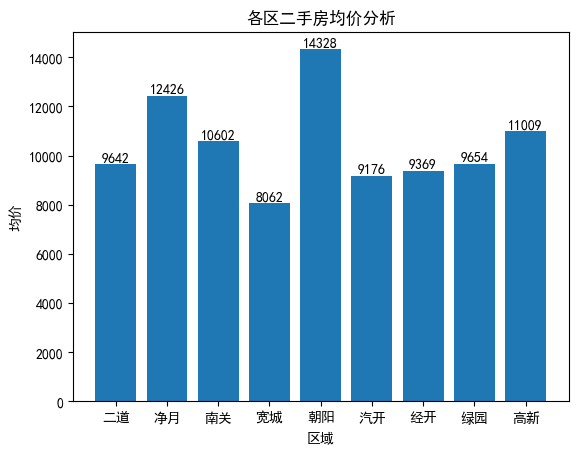

In [11]:
show_average_price(data)

### 2.3各区房子数量比例

- ①各区域分组 ②获取各区域房子数量 ③计算百分比

In [12]:
#获取各区房子数量比例
def get_house_number(data):
    group_number=data.groupby('区域').size()#房子区域分组数量 
    region = group_number.index #区域
    numbers = group_number.values#获取每个区域内房子出售的数量
    percentage=numbers/numbers.sum()*100#计算每个区域房子数量的百分比
    return region,percentage#返回百分比

- ④图标显示数据

In [13]:
#显示各区二手房数量所占比例
def show_house_number(data):
    region,percentage = get_house_number(data)#获取房子区域与数量百分比
    pie_chart(percentage,region,'各区二手房数量占比')#显示图标

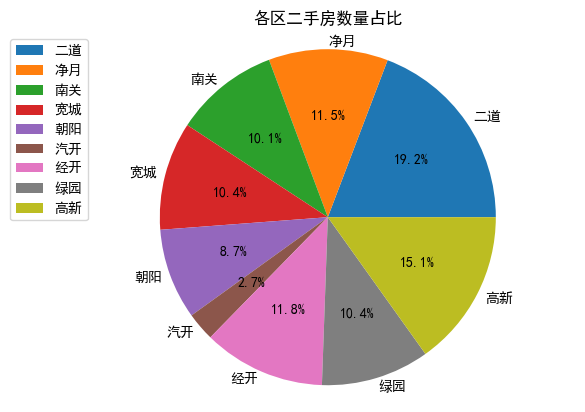

In [14]:
show_house_number(data)

### 2.4二手房装修程度分析

- ①分组二手房装修程度  ②统计分组后数量  ③分离数据

In [15]:
# 获取全市二手房装修程度对比
def get_renovation(data):
    group_renovation = data.groupby('装修').size() #使用groupby分组后的操作 size()求每个分组的行数量
    type = group_renovation.index # 装修程度
    number = group_renovation.values # 获取不同装修程度的房子数量
    return type, number # 返回装修程度与对应的数量

 - ④图标显示数据

In [16]:
# 显示全市二手房装修程度分析
def show_renovation(data):
    type,number = get_renovation(data) # 获取全市房子装修程度
    renovation_bar(type, number,'全市二手房装修程度分析') # 显示图表

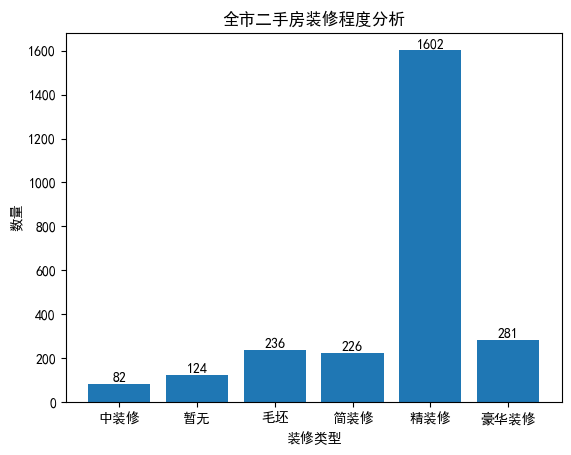

In [17]:
show_renovation(data)

### 2.5热门户型均价分析

- ①户型分组 花去分组对应数量 ②降序处理 ③计算户型均价

In [18]:
#获取二手房热门户型均价
def get_house_mean(data):
    group_hx=data.groupby('户型').size()  #房子户型分组数量
    sort_values=group_hx.sort_values(ascending=False)#将户型分组数量进行降序
    region=sort_values.head(5)#提取前五组户型数据
    group_dj=data.groupby('户型')['单价'].mean()#计算每个户型的均价
    type = group_dj[region.index].index#户型
    price=group_dj[region.index].values#户型对应的均价
    return type,price.astype(int)#返回户型与对应的数量

- ④图标显示数据

In [19]:
#显示热门户型均价分析图
def show_type(data):
    type,price=get_house_mean(data)    #获取全市二手房热门户型均价
    bar(price,type,'热门户型均价分析')

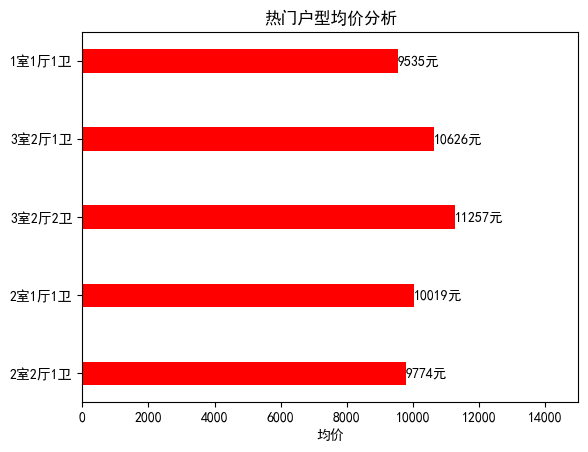

In [20]:
show_type(data)

### 3. 二手房售价预测

#### 3.1 查看数据是否符合分析条件

In [21]:
data_copy = data.copy() # 拷贝数据
print(data_copy[['户型','建筑面积']].head())

       户型   建筑面积
0  2室2厅1卫   89.0
1  3室2厅1卫  143.0
2  1室1厅1卫   43.3
3  2室1厅1卫   57.0
4  3室2厅2卫  160.8


In [22]:
data_copy[['室','厅','卫']] = data_copy['户型'].str.extract('(\d+)室(\d+)厅(\d+)卫')
data_copy['室'] = data_copy['室'].astype(float) # 将房子室转化为浮点类型
data_copy['厅'] = data_copy['厅'].astype(float) # 将房子厅转化为浮点类型
data_copy['卫'] = data_copy['卫'].astype(float) # 将房子卫转化为浮点类型
print(data_copy[['室','厅','卫']].head())       # 打印“室”，“厅”，“卫”

     室    厅    卫
0  2.0  2.0  1.0
1  3.0  2.0  1.0
2  1.0  1.0  1.0
3  2.0  1.0  1.0
4  3.0  2.0  2.0


#### 3.2清洗数据 

In [23]:
del data_copy['小区名字']
del data_copy['户型']
del data_copy['朝向']
del data_copy['楼层']
del data_copy['装修']
del data_copy['区域']
del data_copy['单价']
data_copy.dropna(axis=0, how='any', inplace=True) # 删除data数据中所有的空值
"""
axis：可选函数，表示删除行还是列。默认值为0，表示删除包含缺失值的行；设置为1表示删除包含缺失值的列
how：可选参数，表示删除的条件。默认值为‘any’，表示只要存在一个缺失值就删除整行或整列；设置为‘all’表示只有当整行或整列都是缺失值时才删除
inplace：可选参数，表示是否对原始数据进行就地修改
"""
new_data = data_copy[data_copy['建筑面积']<300].reset_index(drop=True)
# 获取“建筑面积”小于300平米的房子信息#reset_index（）重置索引
new_data

,总价,建筑面积,室,厅,卫
0,89.0,89.00,2.0,2.0,1.0
1,99.8,143.00,3.0,2.0,1.0
2,32.0,43.30,1.0,1.0,1.0
3,51.5,57.00,2.0,1.0,1.0
4,210.0,160.80,3.0,2.0,2.0
...,...,...,...,...,...
2500,115.0,153.95,3.0,2.0,2.0
2501,99.8,91.30,2.0,2.0,1.0
2502,75.0,110.00,2.0,2.0,1.0
2503,100.0,109.73,2.0,2.0,1.0


### 3.3房价预测

In [24]:
from sklearn.svm import LinearSVR
#手动划分训练集和测试集
data_train = new_data.loc[0:2500]
x_list = ['建筑面积','室','厅','卫']             #自变量参考列
data_mean = data_train.mean()                    #获取平均值
data_std = data_train.std()                      #获取标准偏差
data_train = (data_train - data_mean)/data_std   #数据标准化   

x_train = data_train[x_list].values              #特征数据
y_train = data_train['总价'].values              #目标数据 总价
linearsvr = LinearSVR(C=0.1)                     #创建LinearSVR对象
linearsvr.fit(x_train, y_train)                  #训练模型

C:\Users\cloud\.conda\envs\tensorflow\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVR(C=0.1)

In [27]:
new_data.loc[2505] = [None,65.0 , 2.0 , 2.0 , 1.0]  # 添加自定义预测数据
new_data.loc[2506] = [None,91.0 , 2.0 , 2.0 , 2.0]

x = ((new_data[x_list]-data_mean[x_list]) / data_std[x_list]).values # 标准化特征数
new_data2 = new_data.copy()

new_data2[u'y_pred'] = linearsvr.predict(x)*data_std['总价']+data_mean['总价']
# 添加预测房价的信息列
print('真实值与预测值分别为：\n', new_data2[['总价','y_pred']])    

真实值与预测值分别为：
          总价      y_pred
0      89.0   84.859313
1      99.8  143.751951
2      32.0   32.552381
3      51.5   51.005478
4     210.0  178.864322
...     ...         ...
2502   75.0  105.932026
2503  100.0  105.661092
2504   48.8   56.762361
2505    NaN   60.776211
2506    NaN  104.116975

[2507 rows x 2 columns]


### 3.4图表显示数据

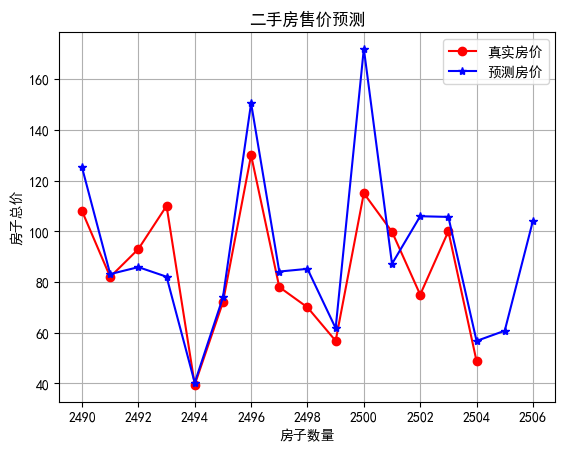

In [28]:
y = new_data2[['总价']][2490:] # 获取2490以后的真实总价
y_pred = new_data2[['y_pred']][2490:] # 获取2490以后的预测总价

# 显示二手房售价预测折线图
def show_total_price(y,y_pred):
    true_price,forecast_price =y ,y_pred # 获取预测房价
    broken_line(true_price,forecast_price,'二手房售价预测') # 绘制及显示图标
show_total_price(y, y_pred)